In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [2]:
model = models.mobilenet_v2(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=learning_rate, momentum=0.9)

# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
#             print(phase,'epoch',":",epoch,'num_imputs',inputs.size())
#             tensor = inputs[0].to(torch.float32).cpu()
#             print(labels[0])
#             # 将张量转换为图像并显示
#             plt.imshow(tensor.permute(1, 2, 0))
#             plt.show()
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_Mobilenet.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

epoch: 0, train Loss: 1.3792 Acc: 0.2965
epoch: 0, val Loss: 1.3096 Acc: 0.4505
epoch: 1, train Loss: 1.0136 Acc: 0.5756
epoch: 1, val Loss: 1.0711 Acc: 0.5000
epoch: 2, train Loss: 0.6358 Acc: 0.8295
epoch: 2, val Loss: 0.8473 Acc: 0.6667
epoch: 3, train Loss: 0.4591 Acc: 0.8837
epoch: 3, val Loss: 0.7224 Acc: 0.7072
epoch: 4, train Loss: 0.3306 Acc: 0.9205
epoch: 4, val Loss: 0.5037 Acc: 0.7973
epoch: 5, train Loss: 0.2877 Acc: 0.9186
epoch: 5, val Loss: 0.4741 Acc: 0.8288
epoch: 6, train Loss: 0.2609 Acc: 0.9360
epoch: 6, val Loss: 0.3026 Acc: 0.8964
epoch: 7, train Loss: 0.1689 Acc: 0.9651
epoch: 7, val Loss: 0.2938 Acc: 0.9189
epoch: 8, train Loss: 0.1545 Acc: 0.9632
epoch: 8, val Loss: 0.2275 Acc: 0.9279
epoch: 9, train Loss: 0.1135 Acc: 0.9845
epoch: 9, val Loss: 0.1813 Acc: 0.9414
epoch: 10, train Loss: 0.0707 Acc: 0.9903
epoch: 10, val Loss: 0.1792 Acc: 0.9414
epoch: 11, train Loss: 0.0726 Acc: 0.9864
epoch: 11, val Loss: 0.1480 Acc: 0.9459
epoch: 12, train Loss: 0.0595 Acc: 0

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

431.4290220737457


In [4]:
torch.save(model.state_dict(), 'Mobilenet.pth')

In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

model = models.mobilenet_v2()
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 加载之前保存的模型参数
model.load_state_dict(torch.load('Mobilenet.pth'))

start_time = time.time()
for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([3, 2, 2, 1, 0, 0, 3, 3, 2, 0, 1, 3, 2, 2, 3, 2, 3, 3, 2, 0, 1, 2, 3, 3,
        0, 1, 2, 3, 3, 1, 1, 3, 1, 2, 2, 3, 3, 2, 3, 1, 1, 2, 1, 3, 1, 2, 2, 0,
        1, 0, 3, 3, 0, 0, 1, 1, 0, 1, 2, 2, 1, 1, 0, 3], device='cuda:0') tensor([3, 2, 0, 1, 0, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 2, 3, 3, 0, 0, 1, 2, 3, 3,
        1, 1, 2, 3, 3, 1, 1, 3, 1, 2, 2, 3, 3, 2, 3, 1, 1, 2, 1, 3, 1, 0, 0, 0,
        1, 0, 3, 3, 0, 0, 2, 1, 0, 1, 2, 2, 1, 1, 0, 3], device='cuda:0')
0.055145345628261566


In [2]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('Mobilenet_con.png', dpi=300)
    plt.tight_layout()

In [3]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[ 8  3  0  0]
 [ 0 16  1  0]
 [ 4  0 13  0]
 [ 0  0  0 19]]


Normalized confusion matrix
[[0.72727273 0.27272727 0.         0.        ]
 [0.         0.94117647 0.05882353 0.        ]
 [0.23529412 0.         0.76470588 0.        ]
 [0.         0.         0.         1.        ]]


<ipython-input-2-49a86b1b6f80>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


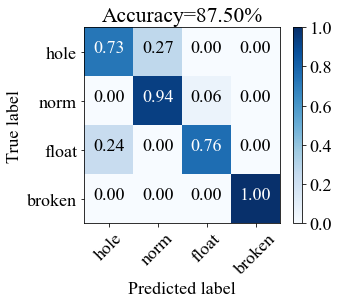

In [4]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)